# COE 292 project


## **Summary of Classification Problem**

The research seeks to establish a system for air quality classification that judges atmospheric conditions into Good, Moderate, Poor and Hazardous classifications using environmental measurements of temperature, humidity, PM10, NO2, SO2, CO, industrial zones and resident settlements. Studies have proven that these environmental characteristics affect air quality through direct or indirect connections. Air quality standards indicate that elevated PM10 and CO levels typically indicate poor air quality however the location near industries together with high population numbers create pollution sources. The main difficulty exists because these classification categories tend to share similar numerical scopes while their feature relationships appear intricate and show non-linear behavior. Standard threshold values together with simple rules cannot effectively distinguish the different classes. Environmental monitoring and public health decisions require classification models to extract pattern relationships which lead to accurate predictions.

# 1. Data Exploratory Analysis

---
  ### 1.a Dataset Manipulation



- ### Dataset Changes  
The dataset was preprocessed to improve quality and ensure reliable analysis.

- ### Missing Values  
There are no missing values. All columns are complete.

- ### Noise (Outliers)  
Outliers were found in some numerical columns and handled using Winsorization, which caps extreme values based on the IQR method. This reduced their effect without removing any data.

- ### Inconsistencies  
No inconsistencies were found.

- ### Feature Reduction  
The `PM2.5` column was dropped due to high correlation with `PM10`. Keeping one was sufficient to avoid redundancy.

**No change to the number of rows in the dataset was conducted. However, one feature column (PM2.5) was removed due to its high correlation with PM10, in order to reduce redundancy and improve model efficiency. Additionally, some outliers were found in numerical features and were handled using Winsorization based on the Interquartile Range (IQR) method. This helped minimize the impact of extreme values without deleting any data. No missing or inconsistent values were found in the dataset.**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving updated_pollution_dataset.csv to updated_pollution_dataset.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('updated_pollution_dataset.csv', delimiter=',')
display(df.info())
display(df.head())

display(df.select_dtypes(include='number').describe())
display(df.select_dtypes(include='object').describe())

display(df['Air Quality'].value_counts(normalize=True) * 100)
display(df.drop(columns=["Air Quality"]).corr())
df2= df.drop(columns=[ "PM2.5"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


None

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


,Air Quality
count,5000
unique,4
top,Good
freq,2000


,proportion
Air Quality,
Good,40.0
Moderate,30.0
Poor,20.0
Hazardous,10.0


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
Temperature,1.000000,0.466456,0.323840,0.425690,0.591969,0.568082,0.685258,-0.589564,0.481692
Humidity,0.466456,1.000000,0.273366,0.359156,0.491977,0.459804,0.567540,-0.479646,0.411630
PM2.5,0.323840,0.273366,1.000000,0.973005,0.333004,0.299582,0.395179,-0.315766,0.278957
PM10,0.425690,0.359156,0.973005,1.000000,0.439916,0.401849,0.518895,-0.425018,0.365734
NO2,0.591969,0.491977,0.333004,0.439916,1.000000,0.571839,0.710792,-0.607710,0.510938
SO2,0.568082,0.459804,0.299582,0.401849,0.571839,1.000000,0.679060,-0.570385,0.475242
CO,0.685258,0.567540,0.395179,0.518895,0.710792,0.679060,1.000000,-0.707581,0.593389
Proximity_to_Industrial_Areas,-0.589564,-0.479646,-0.315766,-0.425018,-0.607710,-0.570385,-0.707581,1.000000,-0.498058
Population_Density,0.481692,0.411630,0.278957,0.365734,0.510938,0.475242,0.593389,-0.498058,1.000000


In [ ]:
# 1. Check for missing values
missing_values = df2.isnull().sum()

# 2. Detect outliers using IQR method for numeric columns
outlier_summary = {}
numeric_cols = df2.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df2[col] < (Q1 - 1.5 * IQR)) | (df2[col] > (Q3 + 1.5 * IQR)))
    outlier_summary[col] = outliers.sum()

# 3. Check for inconsistencies in categorical data
categorical_summary = df2['Air Quality'].value_counts()


# Print all results
print("Missing values per column:\n", missing_values)
print("\nOutliers per numeric column:\n", outlier_summary)
print("\nUnique values in 'Air Quality':\n", categorical_summary)

Missing values per column:
 Temperature                      0
Humidity                         0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

Outliers per numeric column:
 {'Temperature': np.int64(72), 'Humidity': np.int64(19), 'PM10': np.int64(324), 'NO2': np.int64(73), 'SO2': np.int64(124), 'CO': np.int64(45), 'Proximity_to_Industrial_Areas': np.int64(16), 'Population_Density': np.int64(7)}

Unique values in 'Air Quality':
 Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64


In [ ]:
# handling noise values

def cap_outliers(df2, column):
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df2[column] = np.where(df2[column] < lower_bound, lower_bound, np.where(df2[column] > upper_bound, upper_bound, df2[column]))
    return df2

for col in numeric_cols:
    df2 = cap_outliers(df2, col)

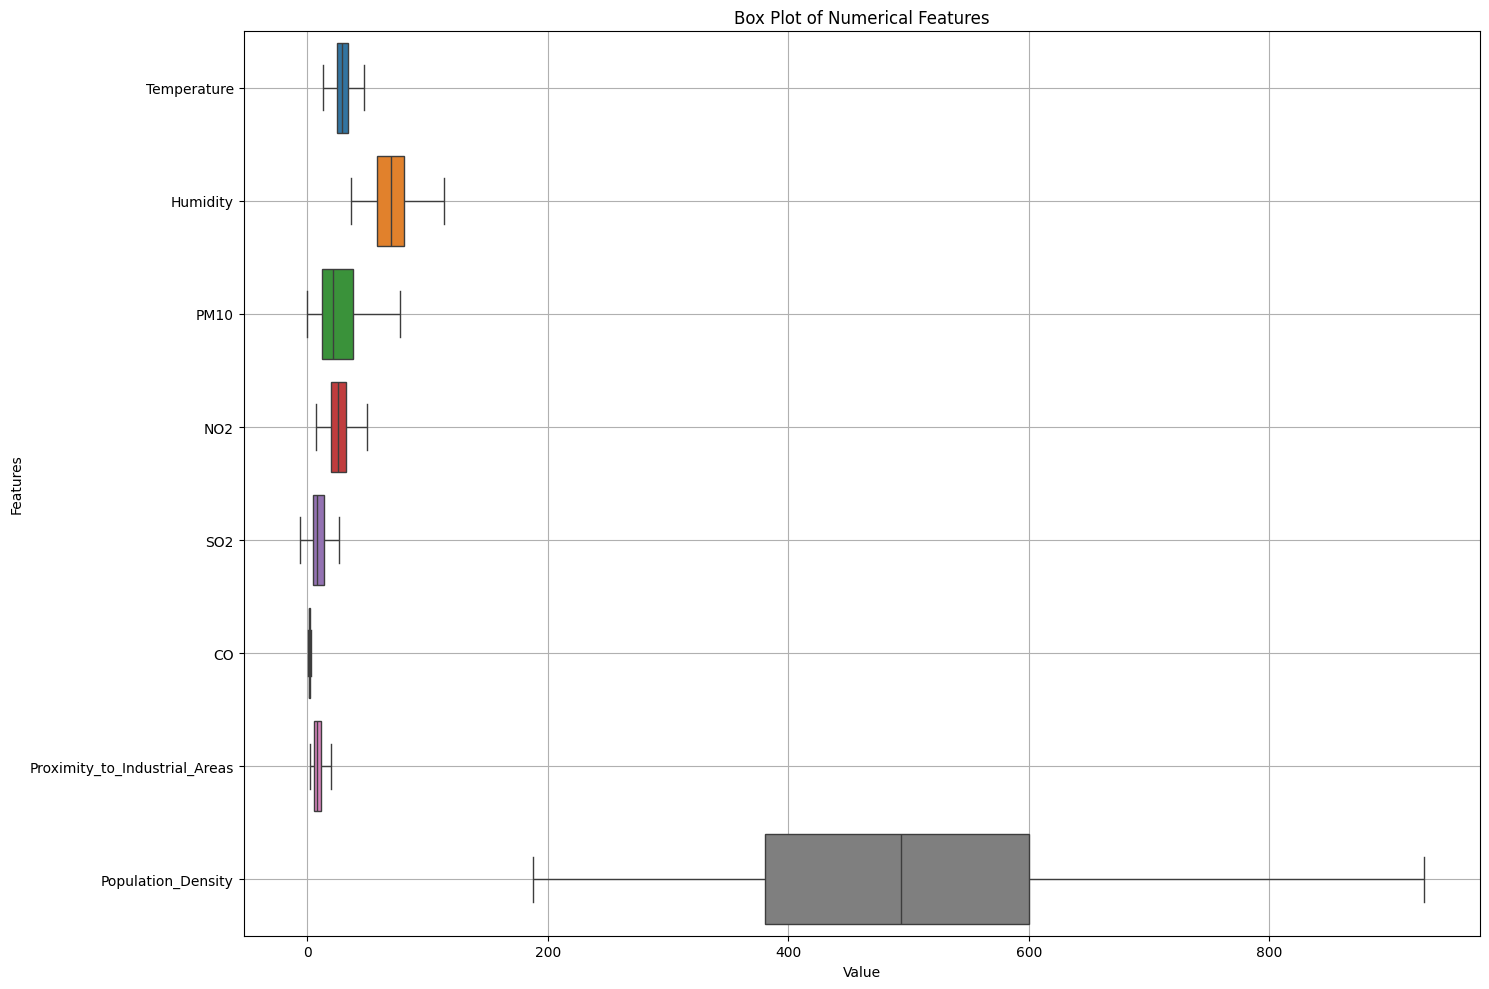

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df2[numeric_cols], orient='h')
plt.title("Box Plot of Numerical Features")
plt.xlabel("Value")
plt.ylabel("Features")
plt.grid(True)
plt.tight_layout()
plt.show()

---
  ### 1.b Label Explanation

**The Air Quality column was label-encoded to convert text categories into numbers for machine learning. No other label changes were made.**

- Good → 0
- Hazardous → 1
- Moderate → 2
- Poor → 3

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encoding target column (since it's categorical)
label_encoder = LabelEncoder()
df2["Air Quality as number"] = label_encoder.fit_transform(df2["Air Quality"])

---
### 1.c Feature Manipulation

**One feature, PM2.5, was removed from the dataset due to its high correlation with PM10, as this could introduce redundancy and affect model performance. No new features were added. All other original features were retained, as they were relevant to predicting air quality and showed no major data quality issues. After splitting the dataset, two types of feature scaling were applied: Standard Scaling (mean = 0, standard deviation = 1) and Min-Max Scaling (scaling values to the [0, 1] range). These preprocessing steps were applied to ensure consistency in feature contribution to model training.**

In [ ]:
# Separating features and target
x = df2.drop(columns=["Air Quality"])
y = label_encoder.fit_transform(df2["Air Quality"])

# Standard Scaling (mean = 0, std = 1)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
standard_scaler = StandardScaler()
x_scaled = standard_scaler.fit_transform(x)

# Splitting the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2 , shuffle = True)


---
  ### **1.d Data Visualization**

#### Plot 1: PM10 vs NO2
- The data shows a significant overlap between air quality categories like Good, Poor, Moderate ,and Hazardous, meaning these classes appear in the same regions of the plot. Also, classification is necessary to identify complex boundaries and patterns that simple rules cannot capture.

---

#### Plot 2: SO2 vs CO
- Air quality classes are heavily overlapped in that the relationship between SO2 and CO and air quality, with no clear separation between them. As such, a classification model is required to learn these intricate patterns and accurately categorize air quality levels.

---

#### Plot 3: Humidity vs PM10
- In this plot, different air quality classes are mixed together, especially in the mid-range values of both features. Classification is needed here to model the non-linear relationships and provide more reliable predictions.

---

#### Plot 4: Proximity to Industrial Areas vs Population Density
- All air quality categories are scattered throughout the plot without any clear grouping. This randomness makes it impossible to draw clear boundaries manually, so classification is essential to detect underlying patterns and assign correct labels.


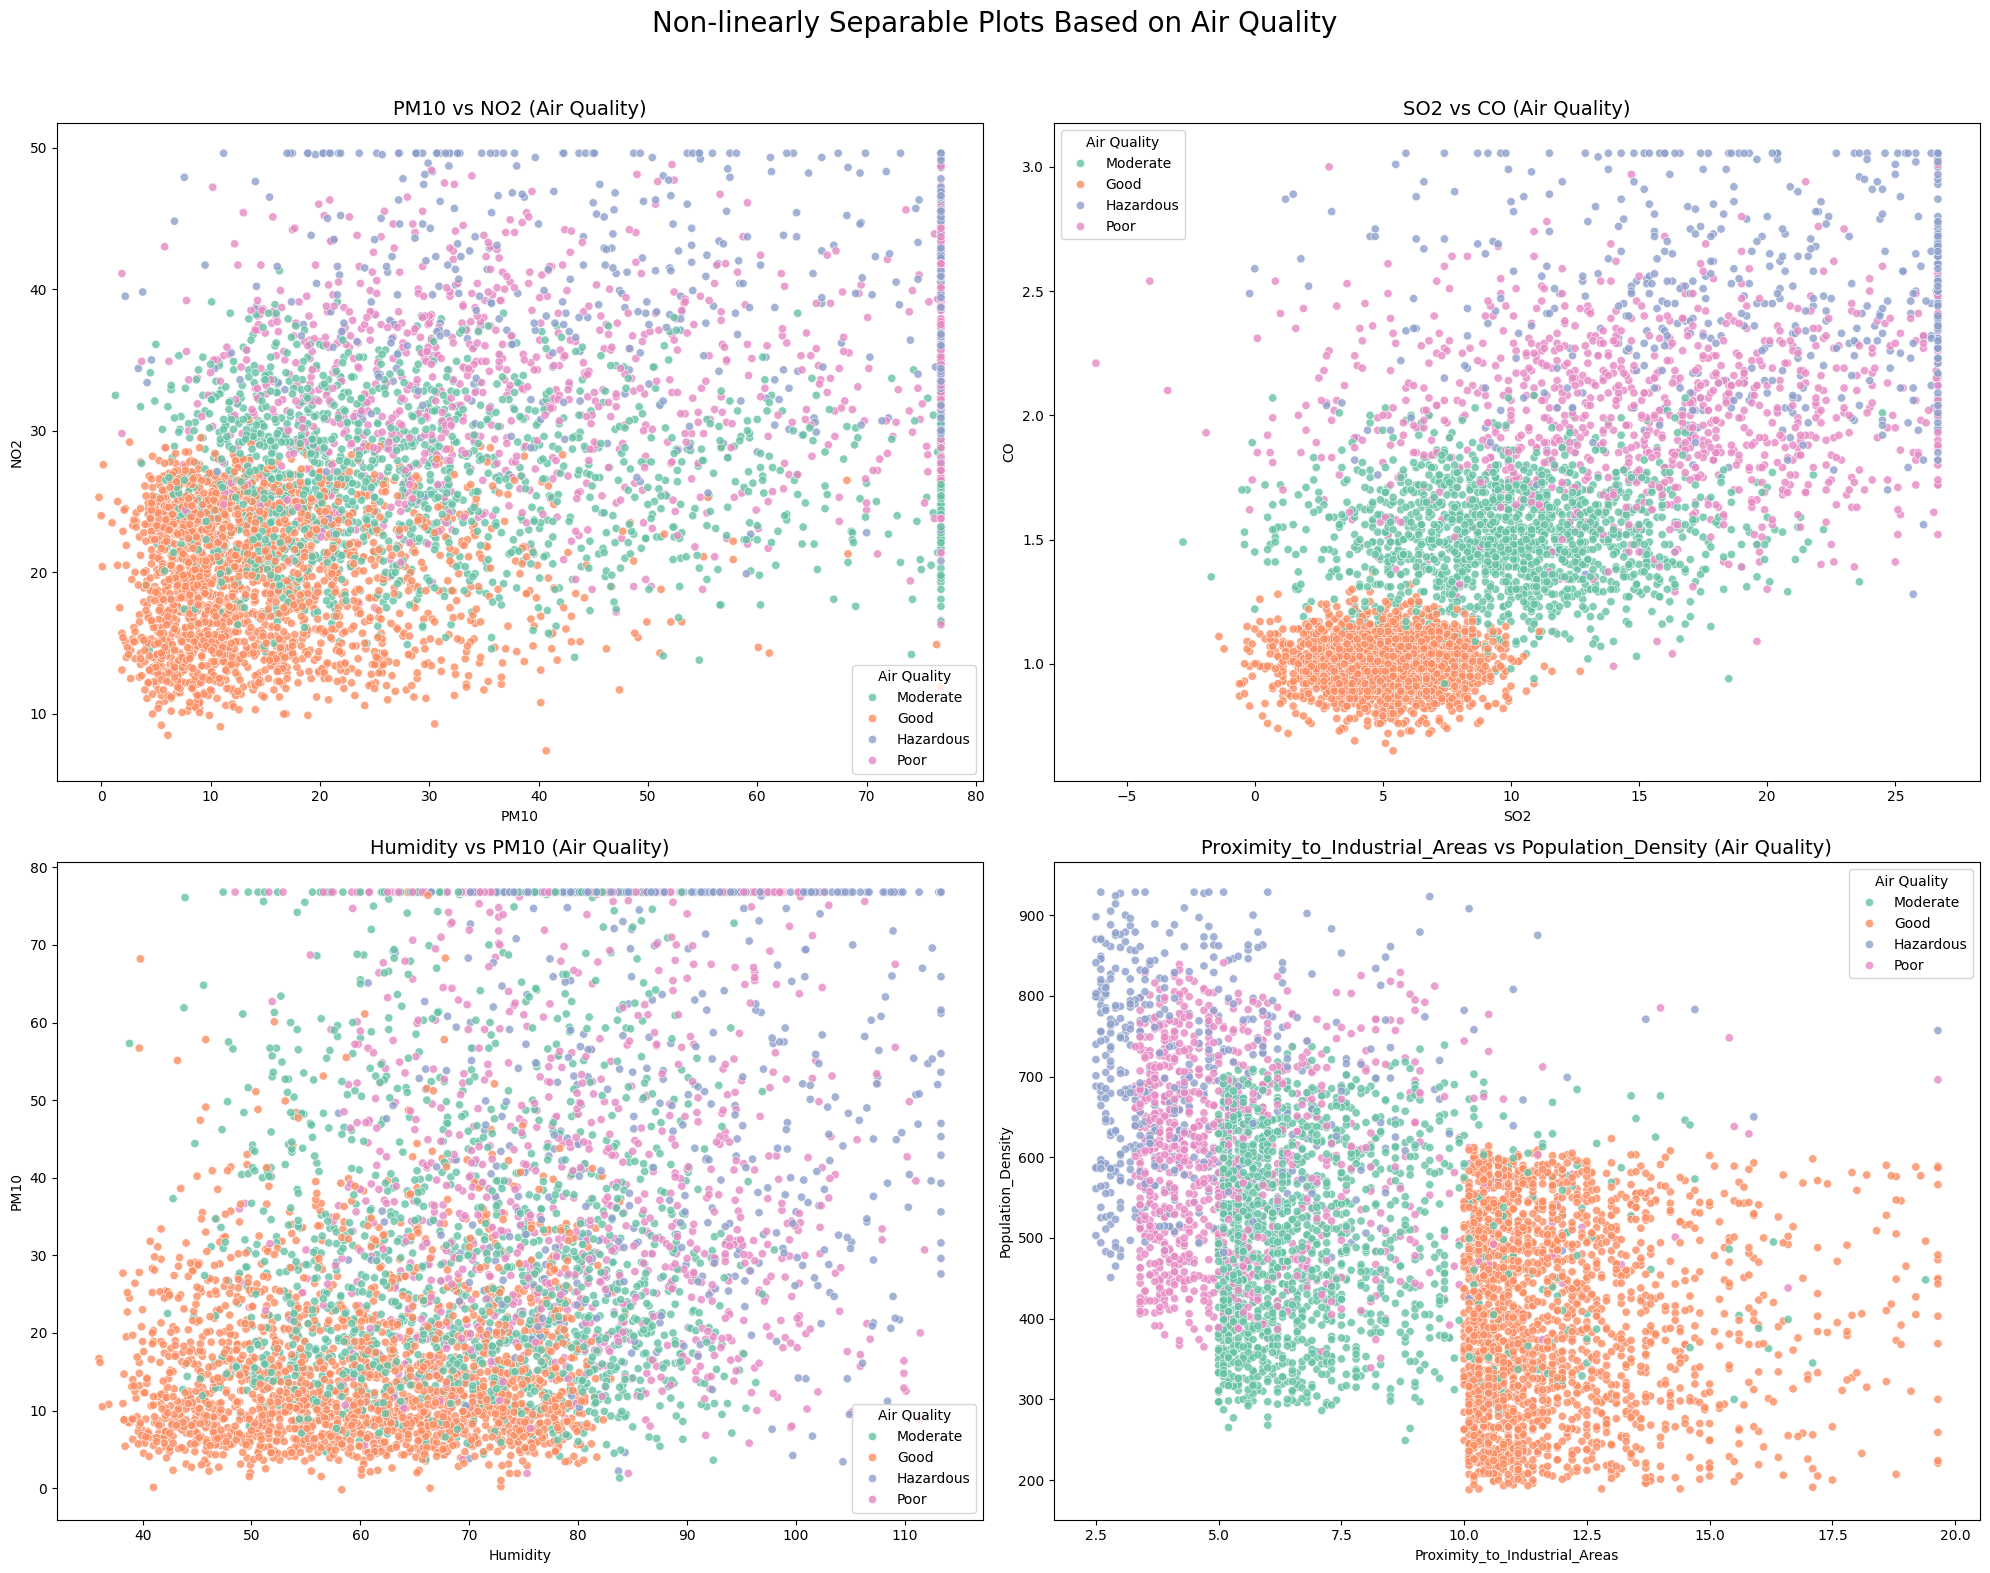

In [ ]:
plt.figure(figsize=(20, 16))

feature_pairs = [
    ("PM10", "NO2"),
    ("SO2", "CO"),
    ("Humidity", "PM10"),
    ("Proximity_to_Industrial_Areas", "Population_Density")
]

for idx, (x_feature, y_feature) in enumerate(feature_pairs, 1):
    plt.subplot(2, 2, idx)
    sns.scatterplot(data=df2, x=x_feature, y=y_feature, hue="Air Quality", palette="Set2", alpha=0.8)
    plt.title(f"{x_feature} vs {y_feature} (Air Quality)", fontsize=14)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend(title="Air Quality")

plt.suptitle("Non-linearly Separable Plots Based on Air Quality", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 1-K-Nearest Neighbors (K-NN)

We used scaled features and tested multiple values of K using cross-validation. The best-performing K was selected based on accuracy.

Performance metrics on the test set include:

Accuracy
Precision
Recall
Confusion Matrix
This model serves as a baseline for comparison with more advanced techniques.

 # Train Test Split

In [ ]:
# Separate features and target
from sklearn.calibration import LabelEncoder

x = df.drop('Air Quality', axis=1)
y = df['Air Quality']

# Encode the target variable (Air Quality) into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets (70-30 split)
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.3, stratify=y_encoded)

# Scale the features using StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Verify scaling (mean should be ~0, std ~1 for training data)
print("\nAfter Scaling - Training Data Statistics:")
print("Mean of Features:", x_train_scaled.mean(axis=0))
print("Standard Deviation of Features:", x_train_scaled.std(axis=0))


After Scaling - Training Data Statistics:
Mean of Features: [-1.36018181e-16  2.13162821e-16  1.11656716e-16  1.16732021e-16
 -3.23804475e-16 -9.33856167e-17 -7.56220483e-17 -1.09626594e-16
 -1.13686838e-16]
Standard Deviation of Features: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


This code sets up a loop to test multiple K values in the KNN algorithm and records both training and test error rates to help find the most accurate model.
## Test different k values
#### Plot error rate vs k

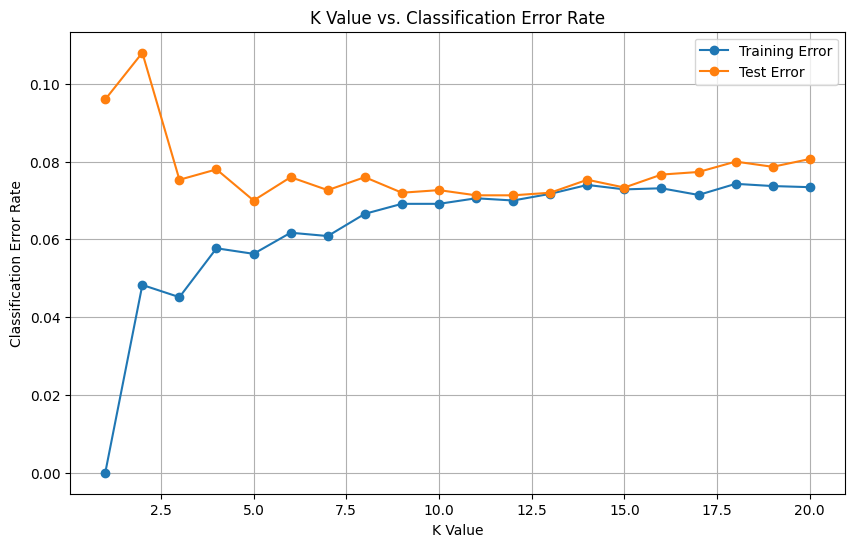

Optimal K: 5 (Test Error: 0.0700)


In [ ]:
# knn alogrithm
from sklearn.neighbors import KNeighborsClassifier
# metrics
from sklearn.metrics import accuracy_score

# Test different K values and calculate error rates
k_values = range(1, 21)
train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)

    # Training error
    train_pred = knn.predict(x_train_scaled)
    train_error = 1 - accuracy_score(y_train, train_pred)
    train_errors.append(train_error)

    # Test error
    test_pred = knn.predict(x_test_scaled)
    test_error = 1 - accuracy_score(y_test, test_pred)
    test_errors.append(test_error)

# Plot K vs. Error Rate
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, label='Training Error', marker='o')
plt.plot(k_values, test_errors, label='Test Error', marker='o')
plt.xlabel('K Value')
plt.ylabel('Classification Error Rate')
plt.title('K Value vs. Classification Error Rate')
plt.legend()
plt.grid(True)
plt.show()

# Find the optimal K (lowest test error)
optimal_k = k_values[np.argmin(test_errors)]
print(f"Optimal K: {optimal_k} (Test Error: {min(test_errors):.4f})")

The plot demonstrates how the classification error rate varies with different K values in a K-Nearest Neighbors (KNN) model, comparing training and test errors. As K increases, training error steadily rises, showing reduced model flexibility, while the test error initially drops and then begins to increase, highlighting the balance between underfitting and overfitting. The optimal K value is identified as 5, where the test error is at its minimum (0.0700), suggesting the best generalization performance on unseen data. The plot is well-structured with clear labels, legend, and gridlines, although adding a vertical marker at the optimal K could further enhance interpretability.

# Create K-NN classifier with the best value of k obtained in the previous step

Classification Report:
              precision    recall  f1-score   support

        Good       0.99      1.00      0.99       600
   Hazardous       0.91      0.75      0.82       150
    Moderate       0.91      0.97      0.94       450
        Poor       0.85      0.83      0.84       300

    accuracy                           0.93      1500
   macro avg       0.91      0.89      0.90      1500
weighted avg       0.93      0.93      0.93      1500


Confusion Matrix:
[[600   0   0   0]
 [  0 112   0  38]
 [  9   0 435   6]
 [  0  11  41 248]]


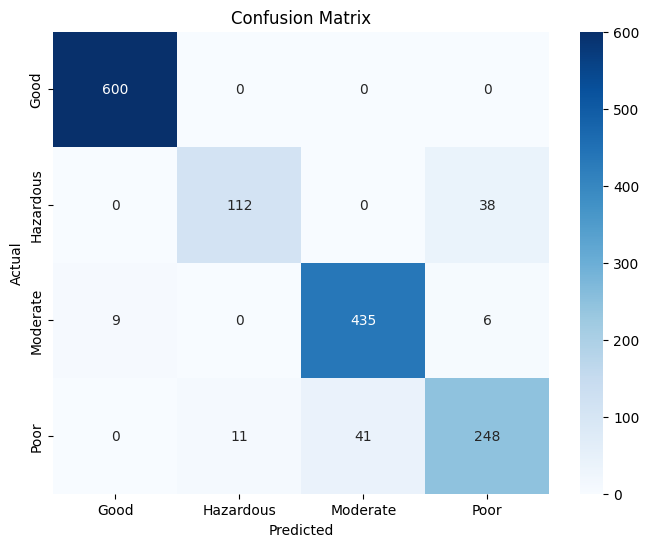


Class: Good
True Positives (TP): 600
False Positives (FP): 9
True Negatives (TN): 891
False Negatives (FN): 0

Class: Hazardous
True Positives (TP): 112
False Positives (FP): 11
True Negatives (TN): 1339
False Negatives (FN): 38

Class: Moderate
True Positives (TP): 435
False Positives (FP): 41
True Negatives (TN): 1009
False Negatives (FN): 15

Class: Poor
True Positives (TP): 248
False Positives (FP): 44
True Negatives (TN): 1156
False Negatives (FN): 52


In [ ]:
# metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Train K-NN with the optimal K
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(x_train_scaled, y_train)

# Predict on the test set
y_pred = knn_optimal.predict(x_test_scaled)

# Classification report (includes accuracy, precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# TP, FP, TN, FN for each class (multi-class adaptation)
# For each class, treat it as the positive class and others as negative
for i, class_name in enumerate(label_encoder.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    print(f"\nClass: {class_name}")
    print(f"True Positives (TP): {TP}")
    print(f"False Positives (FP): {FP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Negatives (FN): {FN}")

The classification performance is summarized using a confusion matrix, classification report, and detailed class-wise metrics. The model achieves an overall accuracy of 93%, with strong performance across most classes, especially for the "Good" and "Moderate" categories, where precision and recall are both high. The confusion matrix confirms that most predictions fall along the diagonal, indicating correct classifications, with few misclassifications between similar classes like "Poor" and "Moderate" or "Hazardous". Class-wise analysis reveals that "Hazardous" has the lowest recall (0.75), affected by a relatively high number of false negatives (38), while "Good" shows excellent performance with very few errors. The model demonstrates good generalization, but slight confusion between adjacent risk levels suggests room for improving class separation, possibly through enhanced feature engineering or class-specific tuning.

# K-nn Model Cross-Validation (5-fold)

The 5-fold cross-validation results provide a reliable estimate of the model's performance consistency. The mean cross-validation accuracy is 91.66%, indicating that the K-NN model with the selected optimal K generalizes well across different data subsets. The low standard deviation of 0.0082 shows that the model’s performance is stable and does not vary much between folds, which supports the robustness of the chosen configuration and reduces concerns about overfitting to a specific train-test split.

In [ ]:
# Perform 5-fold cross-validation with the optimal K
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(knn_optimal, x_train_scaled, y_train, cv=5, scoring='accuracy')

# Report mean and standard deviation of cross-validation scores
print("5-Fold Cross-Validation Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

5-Fold Cross-Validation Scores: [0.90857143 0.92       0.90714286 0.90714286 0.92714286]
Mean CV Accuracy: 0.9140
Standard Deviation: 0.0082


# 2-Support vector machines (SVM)

# SVM Classification and Evaluation

This section illustrates the implementation and evaluation of *Support Vector Machines (SVM)* using both *linear* and *RBF kernels* for classification tasks. Below is the step-by-step workflow:

---

## *1. Data Preparation*
- The features (X) and labels (Y) are pre-processed and split into training and testing datasets.

---

## *2. Model Training and Evaluation*

 ### SVM with Linear Kernel*
- SVM model is initialized with a linear kernel.
- The model is trained on the training dataset.
- Predictions are with the test dataset.
- Performance is evaluated using:
  - *Confusion Matrix*: displays the number of accurate and inaccurate predictions for each class.
  - *Classification Report*: Provides metrics include precision, recall, and F1-score.

 ### SVM with RBF Kernel*
- An SVM model is initialized with an RBF kernel.
- The model is trained on the training dataset.
- Predictions with the test dataset.
- Performance is evaluated using the same metrics as linear kernal.

---

## *3. Visualization*

 ### Confusion Matrix Visualization*
- Heatmaps are created for the confusion matrices of both the linear and RBF kernels.
- These heatmaps provide a straightforward way to interpret the prediction performance for each class.

 ###  Decision Boundary Visualization*
- To visualize decision boundaries, only the two features of the dataset are used.
- A mesh grid is created, and predictions are made for every point on the grid.
- The decision boundary of the *SVM with a linear kernel* is plotted:
  - Data points from the training set are overlaid.
  - This provides a visual representation of how well the model separates the classes.

---

## *4. Key Insights*
1. *Linear Kernel*:
   -  for linearly separable data.
   - Produces a straight-line decision boundary (or a plane in higher dimensions).
2. *RBF Kernel*:
   -  for data that is not linearly separable.
   - Adapts flexibly to the data's shape, providing a non-linear decision boundar

In [ ]:
#import libriries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import LabelEncoder

In [ ]:
#This code to train SVM model
#Initialize SVM model with a linear kernel
svm_model1 = svm.SVC(kernel='linear', random_state=42)

#Fit SVM model on train data
svm_model1.fit(x_train, y_train)

#Predict on test data
y_pred1 = svm_model1.predict(x_test)

#Evaluate the model by confusion matrix and classification report
print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

[[600   0   0   0]
 [  0 132   0  18]
 [  3   0 434  13]
 [  0  12  30 258]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       600
           1       0.92      0.88      0.90       150
           2       0.94      0.96      0.95       450
           3       0.89      0.86      0.88       300

    accuracy                           0.95      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.95      0.95      0.95      1500



In [ ]:
# Try Rbf for different better result
svm_model = svm.SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)
y_pred = svm_model.predict(x_test)
#Evalute the model by confusion matrix and classifacation report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[575   0  25   0]
 [  0  59   5  86]
 [ 96   0 316  38]
 [  2  15 142 141]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       600
           1       0.80      0.39      0.53       150
           2       0.65      0.70      0.67       450
           3       0.53      0.47      0.50       300

    accuracy                           0.73      1500
   macro avg       0.71      0.63      0.65      1500
weighted avg       0.72      0.73      0.72      1500



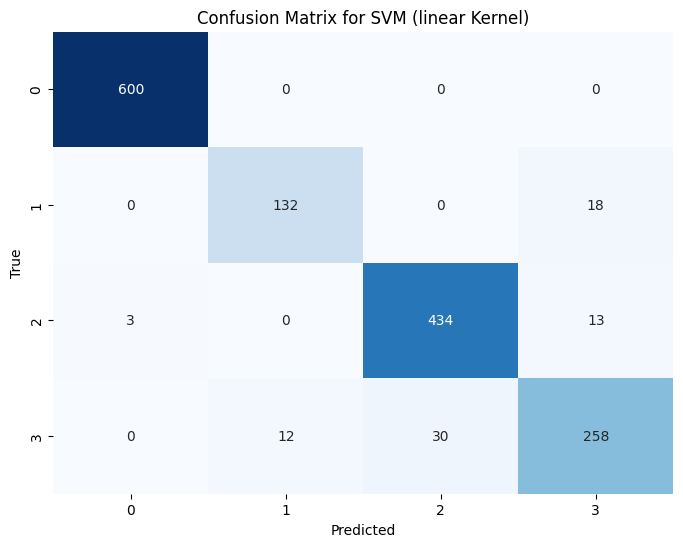

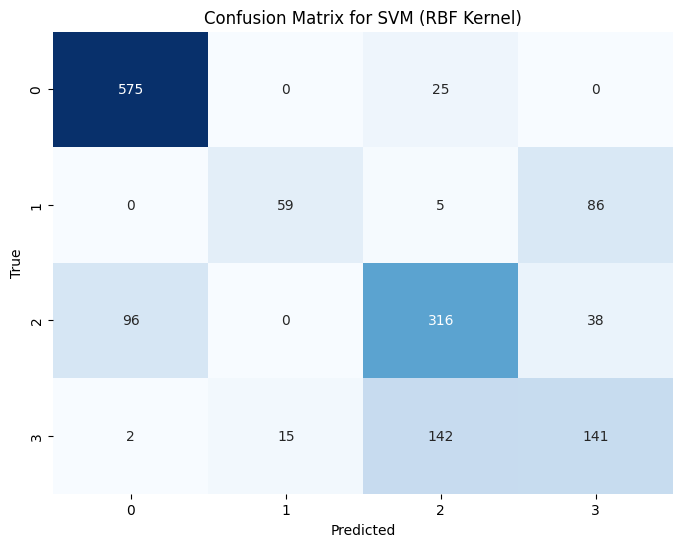

In [ ]:
#Visualizing SVM Decision Boundaries
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
encoder1 = LabelEncoder ()
encoder1.fit(y_test)
# For SVM with linear kernel, we use the y_pred1 from the linear SVM
conf_matrix = confusion_matrix(y_test, y_pred1)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=encoder1.classes_, yticklabels=encoder1.classes_)
plt.title("Confusion Matrix for SVM (linear Kernel)")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For SVM with RBF kernel, we use the y_pred from the RBF SVM
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=encoder1.classes_, yticklabels=encoder1.classes_)
plt.title("Confusion Matrix for SVM (RBF Kernel)")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### The Linear Kernel has significantly higher correct predictions (943) compared to the RBF Kernel (758). Based on the confusion matrices. Linear kernal has less missclassifacation compared to RPF.So,linear Kernel is the better option for our dataset.
## The linear kernel is better for this dataset, as it shows higher accuracy, better precision/recall balance, and stronger performance across all classes.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


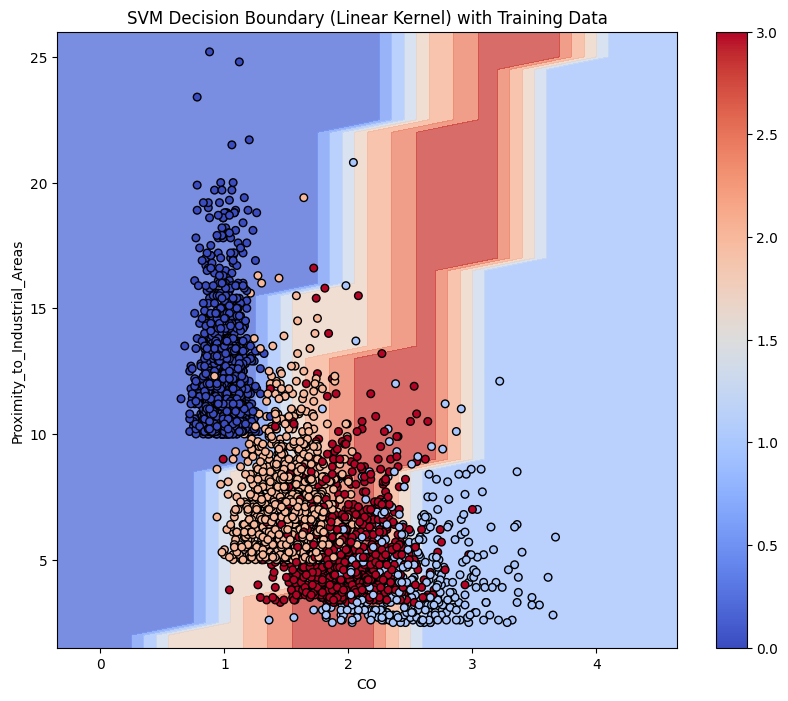

In [ ]:
# Select only two features for 2D visualization( the best correleted data)
x = df[['CO', 'Proximity_to_Industrial_Areas']]
y = df['Air Quality']

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

# Train the SVM model
svm_model1_2d = SVC(kernel='linear', random_state=42)
svm_model1_2d.fit(x_train, y_train)

# Create a mesh grid to plot
h = 0.5  # Step size in the mesh
x_min, x_max = x_train.iloc[:, 0].min() - 1, x_train.iloc[:, 0].max() + 1
y_min, y_max = x_train.iloc[:, 1].min() - 1, x_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict for every point in the mesh grid
Z1 = svm_model1_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)

# Plot the decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z1, alpha=0.75, cmap='coolwarm')
plt.scatter(x_train.iloc[:, 0], x_train.iloc[:, 1], c=y_train, s=30, edgecolors='k', cmap='coolwarm')
plt.title("SVM Decision Boundary (Linear Kernel) with Training Data")
plt.xlabel('CO')
plt.ylabel('Proximity_to_Industrial_Areas')
plt.colorbar()
plt.show()


## SVM Part Explanation

#### 1. *Preparing Data*:  
####   The dataset was divided into training and testing subsets to ensure thet the model was trained on one portion and evaluted on the other.

#### 2. *Training the Model*:  
####  Support Vector Machine (SVM) models were trained to learn patterns within the data . We started with linear kernel to create a straightforward decision boundary. Then, we tested RBF kernel to explore improvements in the preformence.

#### 3. *Evaluting preformence*:  
####   After training, the model were tested on the test dataset. We used metrics such as accuracy, precision, recall, and F1-score, along with confusion matrices to assess class-wise prediction quality. We coclude that linear kernal achive higher accuracy.


#### 4. *Simplifying Visualization*:  
####   To better visualize the classification results, we selected two features and plotted the data in a 2D space, making the decision boundaries easier to interpret.



#### 5. *Drawing Decision Boundaries*:  
####   Visual representations were created to show how each SVM model separated the different classes. These decision boundaries helpe to evalute how well the models performed.

#### 6. *Highlighting Key Data Points*:  
####   We identified and visualized the critical data points (support vectors) that influenced the SVM's decision boundaries the most, providing insight into how the models made predictions.

# 4. Classification Task3 : Deep Learning (ANN)

---
  ### 3.a Dataset Prep/Scaling
**Feature scaling is essential for neural netorks as it improves training stability and speed.**

It prevents large-valued features (e.g., `Population_Density`) from dominating, avoids vanishing/exploding gradients, and ensures more balanced learning across features.

We used the same preprocessed dataset in the early stages, as no modifications were needed. The labels were encoded using `LabelEncoder`, and the input features were scaled using `StandardScaler`.

### 3.b Network Architecture and Activation Functions
The ANN consists of three hidden layers with `ReLU` activation functions and an output layer with `softmax` for multiclass classification. The ANN consists of three hidden layers with `ReLU` activation functions and an output layer with `softmax` for multiclass classification.

**Architecture:**
- Input Layer: 8 features
- Hidden Layers: 64, 32, and 8 neurons (ReLU)
- Output Layer: Softmax activation (4 classes)

**Batch size:** it determines how many training samples the model sees before updating weights. We used a batch size of **16**. Smaller batches help the model escape local minima but require more iterations to complete an epoch.

**Epochs:** We trained the ANN for **100** epochs to allow the model enough time to learn complex relationships in the data.

In [ ]:
# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64,input_shape=(x_train.shape[1],), activation='relu')) # 8**2
model.add(Dense(32, activation='relu')) # 64/2 to give some balance
model.add(Dense(8, activation='relu')) # as the features
model.add(Dense(4,activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Convert y_train and y_test to numeric using LabelEncoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

#Now proceed with your model fitting
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=16)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4092 - loss: 1.2166 - val_accuracy: 0.6590 - val_loss: 0.7444
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7372 - loss: 0.6215 - val_accuracy: 0.8580 - val_loss: 0.4921
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8260 - loss: 0.5056 - val_accuracy: 0.8640 - val_loss: 0.4515
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8429 - loss: 0.4673 - val_accuracy: 0.8590 - val_loss: 0.4248
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8463 - loss: 0.4435 - val_accuracy: 0.8480 - val_loss: 0.4129
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8550 - loss: 0.4202 - val_accuracy: 0.8800 - val_loss: 0.3875
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8530 - loss: 0.3944 - val_accuracy: 0.8750 - val_loss: 0.3666
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8593 - loss: 0.3903 - val_accuracy: 0.8770

### 3.c Model Performance

We evaluate the model using a confusion matrix, accuracy, precision, and recall.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9188 - loss: 0.2201 
Test Accuracy: 0.91
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


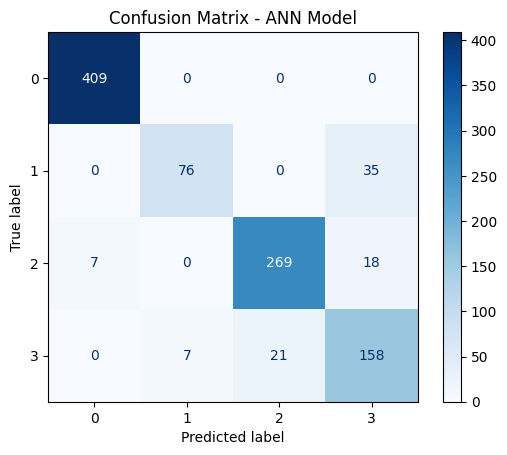

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       409
           1       0.92      0.68      0.78       111
           2       0.93      0.91      0.92       294
           3       0.75      0.85      0.80       186

    accuracy                           0.91      1000
   macro avg       0.89      0.86      0.87      1000
weighted avg       0.92      0.91      0.91      1000


Class: Good
True Positives (TP): 409
False Positives (FP): 7
True Negatives (TN): 584
False Negatives (FN): 0

Class: Hazardous
True Positives (TP): 76
False Positives (FP): 7
True Negatives (TN): 882
False Negatives (FN): 35

Class: Moderate
True Positives (TP): 269
False Positives (FP): 21
True Negatives (TN): 685
False Negatives (FN): 25

Class: Poor
True Positives (TP): 158
False Positives (FP): 53
True Negatives (TN): 761
False Negatives (FN): 28


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate model
_, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Predict test data
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_disp.plot(cmap='Blues')
plt.title("Confusion Matrix - ANN Model")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
#print(model.summary())

# TP, FP, TN, FN for each class (multi-class adaptation)
# For each class, treat it as the positive class and others as negative
for i, class_name in enumerate(label_encoder.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    print(f"\nClass: {class_name}")
    print(f"True Positives (TP): {TP}",)
    print(f"False Positives (FP): {FP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Negatives (FN): {FN}")

## **Comparison (KNN, SVM, DeepNN)**


| Model       | Accuracy (%) | Strengths                                       | Weaknesses                             |
|-------------|--------------|------------------------------------------------|----------------------------------------|
| KNN         |  93.0%       | - Simple & intuitive                          | - Sensitive to irrelevant features & scaling |
|             |              | - Works well on small datasets                | - Slow on large datasets               |
| SVM         | 95.0%       | - Handles high-dimensional data               | - Choice of kernel matters             |
|             |              | - Effective in complex spaces                 | - Slower with large datasets           |
| DeepNN |  91.0%      | - Learns complex patterns                     | - Requires more data                   |
|             |              | - High accuracy on non-linear data            | - Harder to interpret                  |
|             |              |                                                | - Longer training                      |

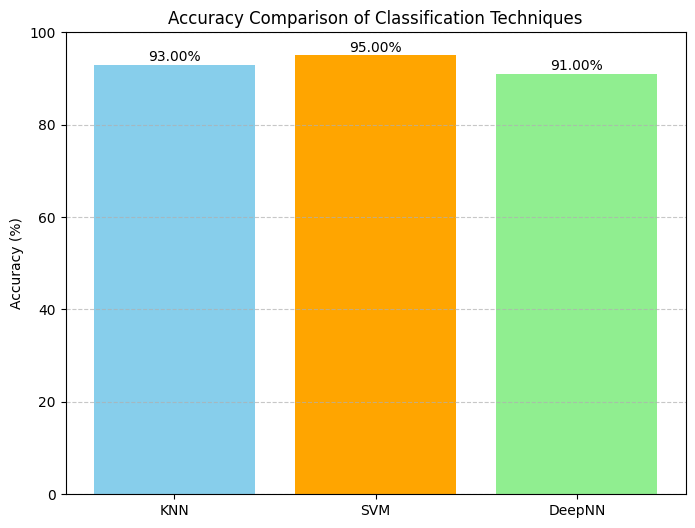

In [ ]:
methods = ['KNN', 'SVM', 'DeepNN']
accuracies = [93.00, 95.00, 91.00]

plt.figure(figsize=(8, 6))
bars = plt.bar(methods, accuracies, color=['skyblue', 'orange', 'lightgreen'])
plt.title('Accuracy Comparison of Classification Techniques')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=10)

plt.show()

## **Conclusion**

We implemented and compared 2 SVM models using both *linear* and *RBF kernels* to classify the data. The results illustrate that the *linear kernel* performed better for pollution dataset, indicating that the data might be linearly separable. By visualizing the confusion matrices and decision boundaries, we gained a clear understanding of how each model predicts and separates the classes. Overall, the linear kernel is more suitable for this data

## **Failure Cases and Limitations**

Despite the high performance of our models, some failure cases were observed—especially with classes that have overlapping environmental indicators, such as “Poor” and “Hazardous” air quality. These classes are harder to separate because they have close values for pollutants like PM2.5 and CO.

One key limitation is the dataset itself. It doesn’t include important context like time, location, or weather, which can affect air quality. Without this extra information, the model might not perform as well in real-world situations.

**Each model also has its challenges:**
- **KNN** was sensitive to feature scaling and local noise, which sometimes caused incorrect predictions.
- **SVM** cstruggles when classes have overlapping values.
- **ANN** may ovirfit when the training data lackes variety or when the data itself is imbalanced.


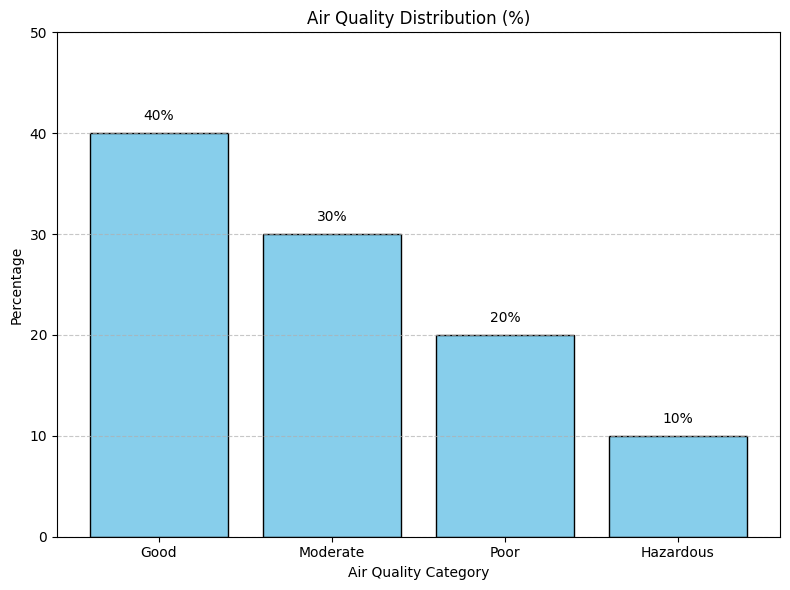

In [ ]:
import matplotlib.pyplot as plt

# Class distribution as percentages
air_quality_distribution = {
    'Good': 40,
    'Moderate': 30,
    'Poor': 20,
    'Hazardous': 10
}

# Plotting bar chart
plt.figure(figsize=(8, 6))
plt.bar(air_quality_distribution.keys(), air_quality_distribution.values(), color='skyblue', edgecolor='black')
plt.title('Air Quality Distribution (%)')
plt.xlabel('Air Quality Category')
plt.ylabel('Percentage')
plt.ylim(0, 50)

# Display percentage labels on top of bars
for i, (category, percentage) in enumerate(air_quality_distribution.items()):
    plt.text(i, percentage + 1, f'{percentage}%', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
